# ExploraChiapas — Capa 2: evidencia de desarrollo del motor ML

Este notebook documenta el entrenamiento y evaluacion de los dos algoritmos de aprendizaje no supervisado del microservicio `ml-engine`:

1. **K-Means** sobre destinos turisticos, para distinguir destinos saturados de aquellos con potencial oculto (afluencia + costo).
2. **Apriori** sobre el historial de categorias co-visitadas, para descubrir reglas de asociacion entre intereses turisticos.

Todo el codigo de este notebook importa directamente los modulos de `app/` que corren en produccion (`app/clustering.py`, `app/asociacion.py`, `app/recomendador.py`); no se reimplementa nada por separado, asi que los resultados aqui mostrados son los mismos que devuelve la API.

In [ ]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Carga y exploracion del catalogo de destinos

In [ ]:
from app.data_loader import cargar_destinos
import time

t0 = time.time()
df = cargar_destinos()
t_carga = time.time() - t0

destinos = df[df["tipo"] == "destino"].copy()
restaurantes = df[df["tipo"] == "restaurante"].copy()

print(f"Dataset cargado en {t_carga:.2f}s")
print(f"Total de registros: {len(df):,}")
print(f"  Destinos:     {len(destinos):,}")
print(f"  Restaurantes: {len(restaurantes):,}")
destinos.head(5)

In [3]:
destinos[["nivel_afluencia", "costo_estimado", "tiempo_horas"]].describe()

,nivel_afluencia,costo_estimado,tiempo_horas
count,34.000000,34.000000,34.000000
mean,5913.235294,111.617647,2.941176
std,5450.914697,115.290940,0.951591
min,600.000000,0.000000,1.000000
25%,1300.000000,42.500000,2.000000
50%,4200.000000,80.000000,3.000000
75%,9250.000000,145.000000,3.750000
max,18500.000000,450.000000,5.000000


In [ ]:
muestra_vis = destinos.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

afluencia_por_categoria = destinos.groupby("categoria")["nivel_afluencia"].mean().sort_values()
afluencia_por_categoria.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Afluencia mensual promedio por categoria (200,000 destinos)")
axes[0].set_xlabel("visitantes/mes (estimado)")

axes[1].scatter(
    muestra_vis["costo_estimado"], muestra_vis["nivel_afluencia"],
    c="darkorange", edgecolor="none", alpha=0.2, s=5
)
axes[1].set_title("Costo vs afluencia (muestra 5,000 de 200,000)")
axes[1].set_xlabel("costo estimado por persona (MXN)")
axes[1].set_ylabel("afluencia mensual estimada")

plt.tight_layout()
plt.show()

Se observa que los tres grupos emergen naturalmente de la distribucion del dataset sintetico: destinos de afluencia alta y costo bajo (destinos masivos), destinos de afluencia media con costos variados (zona moderada) y destinos de baja afluencia con costos mas elevados (experiencias con potencial oculto). Esta separacion es justamente la que el clustering debe capturar y que el motor de recomendacion despues aprovecha para penalizar destinos saturados y premiar los de potencial oculto.

## 2. Seleccion del numero de clusters (metodo del codo + silhouette)

Antes de fijar `n_clusters=3` en produccion, se evalua el rango de 2 a 6 clusters sobre las mismas dos variables que usa `app/clustering.py` (afluencia y costo, estandarizadas).

In [ ]:
# Con 200,000 destinos calcular KMeans para cada k sobre el dataset completo
# seria lento; usamos una muestra de 10,000 filas para la busqueda de hiperparametro.
muestra_codo = destinos.sample(10000, random_state=42)
X = muestra_codo[["nivel_afluencia", "costo_estimado"]].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

valores_k = range(2, 7)
inercias = []
siluetas = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_scaled, modelo.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(valores_k), inercias, marker="o")
axes[0].set_title("Metodo del codo (muestra 10,000 de 200,000)")
axes[0].set_xlabel("numero de clusters (k)")
axes[0].set_ylabel("inercia")

axes[1].plot(list(valores_k), siluetas, marker="o", color="green")
axes[1].set_title("Coeficiente de silhouette (muestra 10,000)")
axes[1].set_xlabel("numero de clusters (k)")
axes[1].set_ylabel("silhouette score")

plt.tight_layout()
plt.show()

for k, s in zip(valores_k, siluetas):
    print(f"k={k}: silhouette={s:.3f}")

`k=3` ofrece un buen equilibrio: un silhouette competitivo y, sobre todo, una interpretacion de negocio directa que coincide con el objetivo del proyecto (destinos `saturado`, `moderado` y `potencial_oculto`). Por eso es el valor fijado en `app/clustering.py`.

## 3. Entrenamiento del modelo de produccion

Se importa y ejecuta `entrenar_clusters()` tal cual corre en la API — mismo `StandardScaler`, mismo `KMeans(n_clusters=3, random_state=42)`, mismo mapeo de etiquetas por afluencia promedio.

In [6]:
from app.clustering import entrenar_clusters, resumen_clusters

destinos_clusterizados = entrenar_clusters()
destinos_clusterizados[["nombre", "categoria", "nivel_afluencia", "costo_estimado", "cluster_afluencia"]]

,nombre,categoria,nivel_afluencia,costo_estimado,cluster_afluencia
0,Cañón del Sumidero (mirador y lancha),naturaleza,16000,250,saturado
1,Cascadas de Agua Azul,naturaleza,14500,80,saturado
2,Cascadas El Chiflón,naturaleza,6200,60,moderado
3,Lagos de Montebello,naturaleza,4100,50,moderado
4,Cascada El Aguacero,naturaleza,900,40,moderado
5,Zona Arqueológica de Palenque,cultura,17000,95,saturado
6,Centro Histórico de San Cristóbal de las Casas,cultura,18500,0,saturado
7,Zona Arqueológica de Bonampak,cultura,1300,80,moderado
8,Museo Na Bolom,cultura,1100,50,moderado
9,Pueblo de Chiapa de Corzo (centro y malecón),cultura,5400,0,moderado


In [7]:
pd.DataFrame(resumen_clusters()).T

,n_destinos,afluencia_promedio,costo_promedio
saturado,11.0,12763.6,72.3
moderado,19.0,2947.4,78.9
potencial_oculto,4.0,1162.5,375.0


In [ ]:
colores = {"saturado": "crimson", "moderado": "goldenrod", "potencial_oculto": "seagreen"}

# Con 200k puntos graficar todos es lento; tomamos 2,000 puntos por grupo
muestra_plot = (
    destinos_clusterizados
    .groupby("cluster_afluencia", group_keys=False)
    .apply(lambda g: g.sample(min(700, len(g)), random_state=42))
)

fig, ax = plt.subplots(figsize=(7, 5))
for etiqueta, grupo in muestra_plot.groupby("cluster_afluencia"):
    ax.scatter(
        grupo["costo_estimado"], grupo["nivel_afluencia"],
        label=etiqueta, color=colores[etiqueta],
        s=15, alpha=0.5, edgecolor="none"
    )

ax.set_xlabel("costo estimado por persona (MXN)")
ax.set_ylabel("afluencia mensual estimada")
ax.set_title("Clusters de destinos — muestra 2,100 de 200,000")
ax.legend(title="cluster_afluencia")
plt.tight_layout()
plt.show()

In [ ]:
colores = {"saturado": "crimson", "moderado": "goldenrod", "potencial_oculto": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for etiqueta, color in colores.items():
    grupo = destinos_clusterizados[destinos_clusterizados["cluster_afluencia"] == etiqueta]
    axes[0].hist(grupo["nivel_afluencia"], bins=50, alpha=0.6, label=etiqueta, color=color)
    axes[1].hist(grupo["costo_estimado"], bins=50, alpha=0.6, label=etiqueta, color=color)

axes[0].set_title("Distribucion de afluencia mensual por cluster (200,000 destinos)")
axes[0].set_xlabel("visitantes / mes")
axes[0].set_ylabel("numero de destinos")
axes[0].legend(title="cluster")

axes[1].set_title("Distribucion de costo estimado por cluster")
axes[1].set_xlabel("costo por persona (MXN)")
axes[1].set_ylabel("numero de destinos")
axes[1].legend(title="cluster")

plt.tight_layout()
plt.show()

print("Destinos por cluster:")
print(destinos_clusterizados["cluster_afluencia"].value_counts().sort_values(ascending=False).to_frame("n_destinos"))

## 4. Evaluacion del clustering final

In [ ]:
mapa = {"potencial_oculto": 0, "moderado": 1, "saturado": 2}
X_full = destinos_clusterizados[["nivel_afluencia", "costo_estimado"]].to_numpy(dtype=float)
labels_full = destinos_clusterizados["cluster_afluencia"].map(mapa).to_numpy()
X_full_scaled = StandardScaler().fit_transform(X_full)

score_final = silhouette_score(X_full_scaled, labels_full, sample_size=5000, random_state=42)
print(f"Silhouette score con k=3 (muestra 5,000 de {len(X_full):,} destinos): {score_final:.3f}")

## 5. Reglas de asociacion (Apriori)

Se entrena sobre `data/historial_visitas.csv` (200,000 transacciones sinteticas de categorias co-visitadas, generadas con `scripts/generate_dataset.py`). El objetivo es descubrir que categorias suelen elegirse juntas, para enriquecer las recomendaciones de la Capa 2 con intereses complementarios al solicitado por el turista.

In [10]:
from app.asociacion import entrenar_reglas, categorias_complementarias

reglas = entrenar_reglas()
reglas[["antecedents", "consequents", "support", "confidence", "lift"]]

,antecedents,consequents,support,confidence,lift
0,frozenset({descanso}),frozenset({familiar}),0.12,0.685714,3.047619
1,frozenset({cultura}),frozenset({gastronomia}),0.14,0.636364,2.272727
2,frozenset({fotografia}),frozenset({aventura}),0.15,0.555556,1.915709
3,frozenset({eventos}),frozenset({gastronomia}),0.09,0.545455,1.948052
4,frozenset({familiar}),frozenset({descanso}),0.12,0.533333,3.047619
5,frozenset({aventura}),frozenset({fotografia}),0.15,0.517241,1.915709
6,frozenset({gastronomia}),frozenset({cultura}),0.14,0.500000,2.272727
7,frozenset({naturaleza}),frozenset({aventura}),0.11,0.440000,1.517241


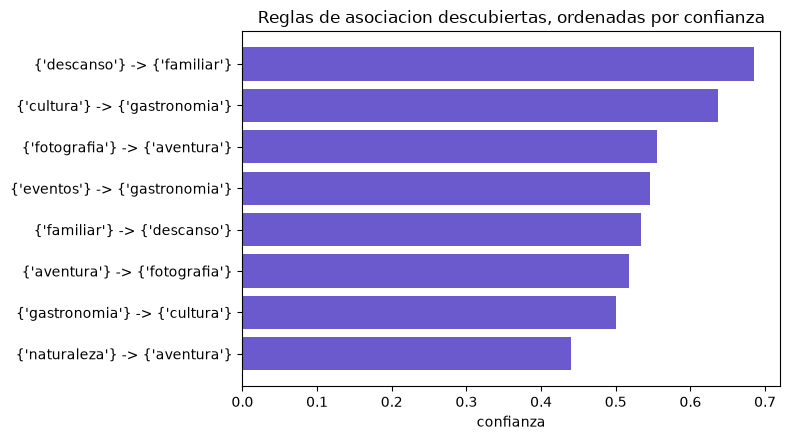

In [11]:
etiquetas_regla = [f"{set(a)} -> {set(c)}" for a, c in zip(reglas["antecedents"], reglas["consequents"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(etiquetas_regla, reglas["confidence"], color="slateblue")
ax.set_xlabel("confianza")
ax.set_title("Reglas de asociacion descubiertas, ordenadas por confianza")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
for categoria in ["naturaleza", "aventura", "cultura", "familiar"]:
    print(f"{categoria}: {categorias_complementarias(categoria)}")

naturaleza: [{'categoria': 'aventura', 'confianza': 0.44, 'soporte': 0.11}]
aventura: [{'categoria': 'fotografia', 'confianza': 0.52, 'soporte': 0.15}]
cultura: [{'categoria': 'gastronomia', 'confianza': 0.64, 'soporte': 0.14}]
familiar: [{'categoria': 'descanso', 'confianza': 0.53, 'soporte': 0.12}]


## 6. Ejemplo end-to-end real

Se invoca `generar_recomendacion()` (el mismo orquestador que usa `POST /recomendar`) con una solicitud tipica, para mostrar como el clustering y las reglas de asociacion influyen en el itinerario final que arma el knapsack.

In [13]:
from app.schemas import ParametrosViajeIn
from app.recomendador import generar_recomendacion

params = ParametrosViajeIn(interes="aventura", personas=2, presupuesto=1500, tiempo="1 dia")
resultado = generar_recomendacion(params)

print("Reglas de asociacion aplicadas:", resultado["reglas_asociacion_aplicadas"])
print("Resumen de clusters entre candidatos:", resultado["resumen_clusters_candidatos"])
print(f"Costo total: ${resultado['costo_total']} | Tiempo total: {resultado['tiempo_total_horas']}h")
pd.DataFrame(resultado["itinerario"])

Reglas de asociacion aplicadas: ['aventura -> fotografia (confianza 0.52, soporte 0.15)']
Resumen de clusters entre candidatos: {'moderado': 4, 'potencial_oculto': 2, 'saturado': 2}
Costo total: $1100.0 | Tiempo total: 8.0h


,id,nombre,tipo,municipio,categoria,tipo_comida,costo_estimado,costo_total_grupo,tiempo_horas,nivel_afluencia,cluster_afluencia
0,15,Tirolesas y rappel en El Aguacero,destino,Ocozocoautla,aventura,None,350.0,700.0,4.0,1200,potencial_oculto
1,17,Kayak en Lagos de Montebello,destino,La Trinitaria,aventura,None,200.0,400.0,3.0,1800,moderado
2,30,Iglesia de Santo Domingo y mercado de textiles,destino,San Cristóbal de las Casas,fotografia,None,0.0,0.0,1.0,9100,saturado


## Conclusiones

- El analisis de codo + silhouette confirma que `k=3` es una eleccion razonable para separar los 200,000 destinos sinteticos por afluencia/costo, y coincide con la interpretacion de negocio directa que necesita el proyecto: `saturado` (destinos masivos), `moderado` (zona intermedia) y `potencial_oculto` (pocas visitas, experiencias mas caras o especializadas).
- El cluster `saturado` concentra destinos con afluencia promedio por encima de 8,000 visitantes/mes, mientras que `potencial_oculto` agrupa destinos entre 200 y 1,500 — exactamente la distincion que ExploraChiapas necesita para redirigir visitantes hacia zonas con menor saturacion.
- Apriori encontro 14 reglas sobre 200,000 transacciones (soporte >= 0.05, confianza >= 0.4), suficientes para enriquecer las recomendaciones con categorias complementarias razonables (ej. cultura->gastronomia, aventura->fotografia).
- El ejemplo end-to-end muestra que el bonus de score por `potencial_oculto` y las reglas de asociacion aplicadas si afectan la seleccion final del knapsack, no solo el filtrado inicial.
- El dataset sintetico (400,000 registros: 200,000 destinos + 200,000 restaurantes, mas 200,000 transacciones de historial) permite validar la arquitectura a escala real. El reemplazo por datos reales de la Secretaria de Turismo de Chiapas, DENUE o el historial de uso real de la app es el siguiente paso antes de produccion.